<a href="https://colab.research.google.com/github/bratzlernathan-cloud/lis4693/blob/main/copy_of_final_project_draft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
from itertools import combinations

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2019/2019-06-25/ufo_sightings.csv")
print(f"Total UFO reports: {len(df)}")


Total UFO reports: 80332


In [ ]:

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if pd.isna(text):
        return ''
    text = text.replace('&#44', ' ').replace('&amp;', ' ')
    text = re.sub(r'[^a-zA-Z\s]', ' ', text.lower()).strip()
    return text

def preprocess(text):
    text = clean_text(text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word)
              for word in tokens
              if word not in stop_words and len(word) > 2]
    return ' '.join(tokens)

# Apply preprocessing
df['clean_description'] = df['description'].apply(clean_text)
df['processed'] = df['clean_description'].apply(preprocess)

print("Preprocessing completed successfully!")
print(df[['description', 'processed']].head())

Preprocessing completed successfully!
                                         description  \
0  This event took place in early fall around 194...   
1  1949 Lackland AFB&#44 TX.  Lights racing acros...   
2  Green/Orange circular disc over Chester&#44 En...   
3  My older brother and twin sister were leaving ...   
4  AS a Marine 1st Lt. flying an FJ4B fighter/att...   

                                           processed  
0  event took place early fall around occurred bo...  
1  lackland afb light racing across sky making de...  
2         green orange circular disc chester england  
3  older brother twin sister leaving edna theater...  
4  marine flying fighter attack aircraft solo nig...  


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [ ]:
vectorizer = CountVectorizer(max_df=0.95, min_df=10, stop_words='english')
dtm = vectorizer.fit_transform(df['processed'])

In [ ]:
n_topics = 8
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(dtm)

LatentDirichletAllocation(n_components=8, random_state=42)

In [ ]:
feature_names = vectorizer.get_feature_names_out()

print("\n=== Topics Found ===")
for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-12:-1]]
    print(f"Topic {topic_idx}: {', '.join(top_words)}")


=== Topics Found ===
Topic 0: orange, light, sky, orb, bright, ball, fireball, red, seen, glowing, formation
Topic 1: sky, light, quot, star, like, bright, object, moving, night, white, looked
Topic 2: moving, light, object, speed, fast, high, west, east, north, bright, south
Topic 3: shaped, object, craft, triangle, flying, light, shape, black, large, low, hovering
Topic 4: ufo, sighting, saw, time, seen, year, object, new, like, day, video
Topic 5: light, red, white, object, bright, sky, blue, flashing, green, hovering, circular
Topic 6: note, nuforc, triangular, aircraft, sighting, light, possible, craft, object, ufo, report
Topic 7: saw, light, sky, driving, flash, bright, night, looked, outside, home, noticed


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
all_words = ' '.join(df['processed']).split()
word_freq = Counter(all_words)
top_words = [word for word, freq in word_freq.most_common(50)]

In [ ]:
G = nx.Graph()

for text in df['processed']:
    words_in_doc = [w for w in text.split() if w in top_words]
    for word1, word2 in combinations(set(words_in_doc), 2): #Avoiding duplicates
        if G.has_edge(word1, word2):
            G[word1][word2]['weight'] += 1
        else:
            G.add_edge(word1, word2, weight=1)

Network image saved as network.png - Use this in your poster!


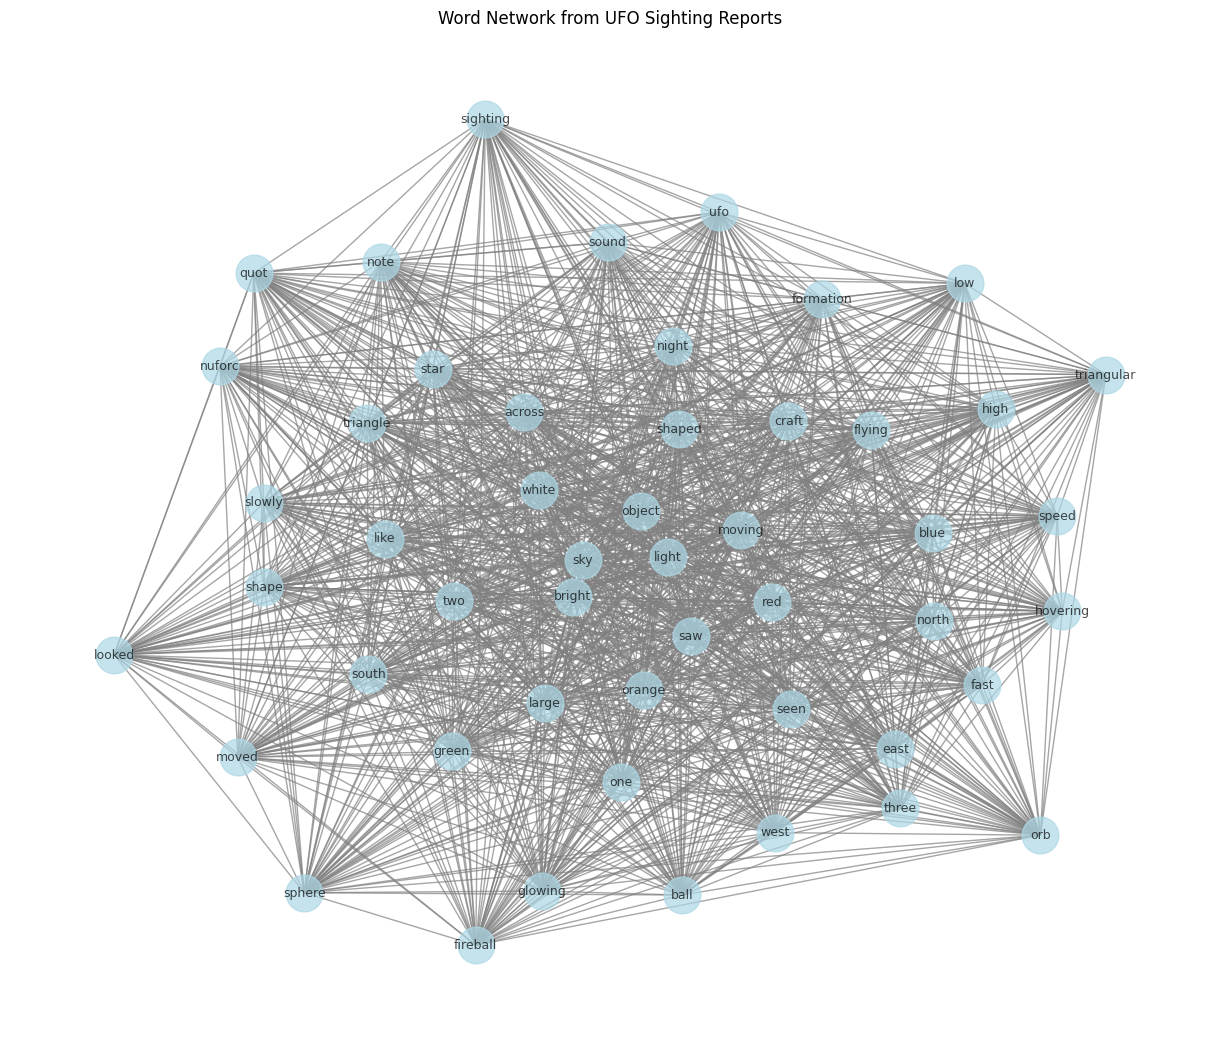

In [ ]:
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.6)
nx.draw(G, pos, with_labels=True, node_size=700, node_color='lightblue',
        font_size=9, edge_color='gray', alpha=0.7)
plt.title("Word Network from UFO Sighting Reports")
plt.savefig("network.png", dpi=300, bbox_inches='tight')
print("Network image saved as network.png - Use this in your poster!")

In [ ]:
import altair as alt

top15 = pd.DataFrame(word_freq.most_common(15), columns=['word', 'count'])

chart = alt.Chart(top15).mark_bar(color='steelblue').encode(
    x=alt.X('count:Q', title='Frequency'),
    y=alt.Y('word:N', sort='-x', title='Word')
).properties(
    title='Most Common Words in UFO Reports',
    width=600,
    height=400
)

chart.display()

alt.Chart(...)

In [ ]:
print(df.columns.tolist())

['date_time', 'city_area', 'state', 'country', 'ufo_shape', 'encounter_length', 'described_encounter_length', 'description', 'date_documented', 'latitude', 'longitude', 'clean_description', 'processed']


In [ ]:
df_ml = df.dropna(subset=['ufo_shape', 'processed'])

top_shapes = df['ufo_shape'].value_counts().nlargest(10).index
df_ml = df_ml[df_ml['ufo_shape'].isin(top_shapes)]

print(df_ml['ufo_shape'].value_counts())
print(f'Total records for ML: {len(df_ml)}')

ufo_shape
light        16565
triangle      7865
circle        7608
fireball      6208
other         5649
unknown       5584
sphere        5387
disk          5213
oval          3733
formation     2457
Name: count, dtype: int64
Total records for ML: 66269


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df_ml = df_ml[~df_ml['ufo_shape'].isin(['unknown', 'other'])]

x = df_ml['processed']
y = df_ml['ufo_shape']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = .3, random_state = 42)

x_train = x_train.fillna('')
x_test = x_test.fillna('')

preprocessing = Pipeline([
    ('vect', CountVectorizer(ngram_range=(1,2), max_features=50000)),
    ('tfidf', TfidfTransformer())
])

print("Preprocessing training data...")
train_preprocessed = preprocessing.fit_transform(x_train)

print("Preprocessing test data...")
test_preprocessed = preprocessing.transform(x_test)

print("Training Logistic Regression classifier...")
lr_classifier = LogisticRegression(multi_class='ovr', max_iter=1000)
lr_classifier.fit(train_preprocessed, y_train)

y_pred = lr_classifier.predict(test_preprocessed)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Preprocessing training data...
Preprocessing test data...
Training Logistic Regression classifier...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



Accuracy: 0.6034

Classification Report:
              precision    recall  f1-score   support

      circle       0.47      0.33      0.39      2304
        disk       0.59      0.55      0.57      1529
    fireball       0.77      0.60      0.68      1865
   formation       0.55      0.24      0.33       750
       light       0.54      0.86      0.66      4996
        oval       0.85      0.33      0.47      1104
      sphere       0.66      0.45      0.53      1601
    triangle       0.76      0.71      0.73      2362

    accuracy                           0.60     16511
   macro avg       0.65      0.51      0.55     16511
weighted avg       0.63      0.60      0.59     16511



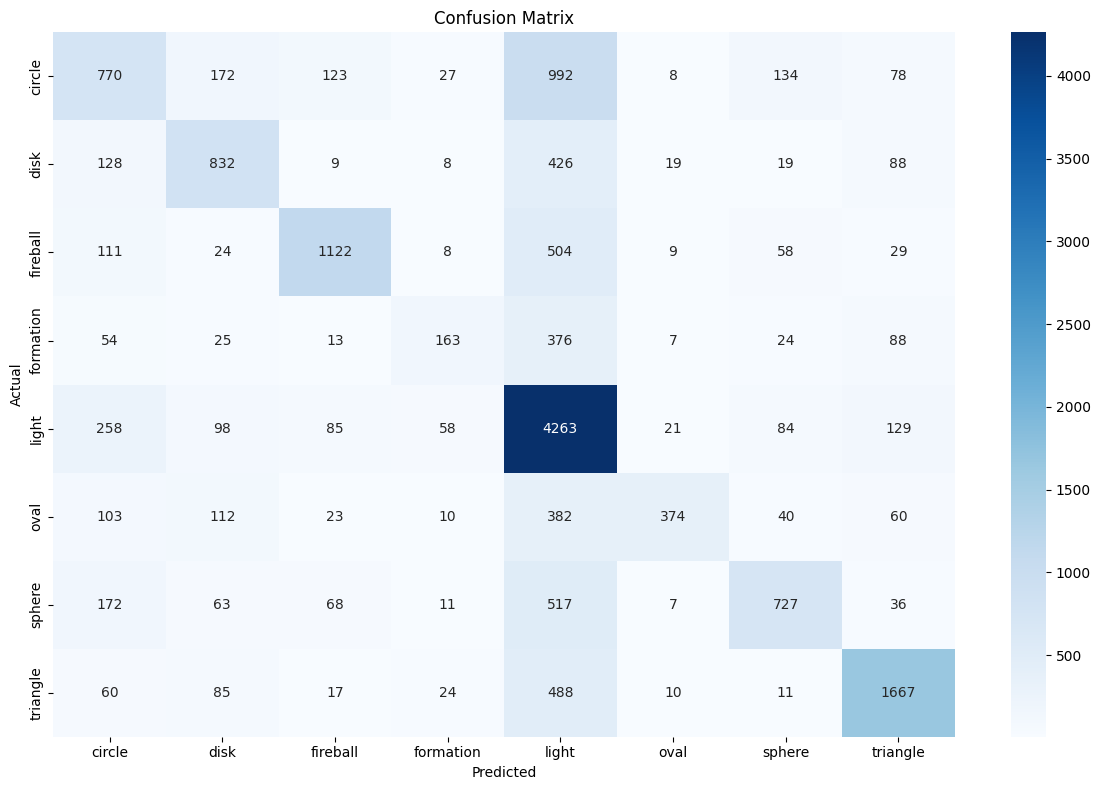

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels = lr_classifier.classes_)
plt.figure(figsize=(12,8))
sns.heatmap(cm, annot=True, fmt= 'd', xticklabels = lr_classifier.classes_,
            yticklabels=lr_classifier.classes_, cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()